# Exercício-síntese da fase

IBOV, PETR4, VALE3, ITUB4 e CDI desde 2015.

1. Baixar os dados
2. Retorno anualizado, vol anualizada, Sharpe, Sortino, max drawdown e matriz de correlação
3. Curvas de patrimônio base 100 + CDI acumulado

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from bcb import sgs

In [2]:
START = "2015-01-01"

TICKERS = ["^BVSP", "PETR4.SA", "VALE3.SA", "ITUB4.SA"]

NOMES = {
    "^BVSP": "IBOV",
    "PETR4.SA": "PETR4",
    "VALE3.SA": "VALE3",
    "ITUB4.SA": "ITUB4",
}

## 1. Dados

Os preços vêm do Yahoo (`auto_adjust=True`, já ajustados por proventos e splits).
O CDI vem da série 12 do SGS/BCB, que é a **taxa diária em %** — ou seja, já é um
retorno. Por isso ele fica em uma Series separada e nunca entra na tabela de preços:
aplicar `pct_change()` nele daria a variação da *taxa*, não o retorno do CDI.

In [3]:
def baixar_precos(tickers, start=START):
    data = yf.download(tickers, start=start, auto_adjust=True, progress=False)
    return data["Close"][tickers]


def baixar_cdi(start=START, end=None):
    """CDI da serie 12 do SGS/BCB, ja como taxa diaria decimal.

    O SGS recusa janelas maiores que 10 anos em series diarias, entao a
    consulta e quebrada em blocos de 9 anos e remendada.
    """
    inicio = pd.Timestamp(start)
    fim = pd.Timestamp(end) if end else pd.Timestamp.today().normalize()

    partes = []
    while inicio <= fim:
        corte = min(inicio + pd.DateOffset(years=9), fim)
        partes.append(sgs.get({"cdi": 12}, start=inicio.date(), end=corte.date())["cdi"])
        inicio = corte + pd.Timedelta(days=1)

    return pd.concat(partes) / 100

In [4]:
precos = baixar_precos(TICKERS).dropna()
cdi_bruto = baixar_cdi()

print("precos:", precos.index.min().date(), "->", precos.index.max().date(), precos.shape)
print("cdi   :", cdi_bruto.index.min().date(), "->", cdi_bruto.index.max().date(), cdi_bruto.shape)

precos: 2015-01-02 -> 2026-09-10 (2902, 4)
cdi   : 2015-01-02 -> 2026-09-09 (2932,)


In [5]:
# retornos diarios dos 4 ativos
ret = precos.pct_change().dropna()

# CDI no mesmo calendario: ffill sobre a uniao das datas, depois recorta no indice de ret.
# O ffill sobre a uniao evita perder um dia de CDI que nao exista no pregao da B3.
cdi = (
    cdi_bruto.reindex(cdi_bruto.index.union(ret.index))
    .ffill()
    .reindex(ret.index)
)

# descarta o trecho inicial em que o CDI ainda nao existe
validos = cdi.notna()
ret, cdi = ret[validos], cdi[validos]

ret = ret.rename(columns=NOMES)
print(f"{len(ret)} pregoes de {ret.index.min().date()} a {ret.index.max().date()}")
ret.head()

2901 pregoes de 2015-01-05 a 2026-09-10


Ticker,IBOV,PETR4,VALE3,ITUB4
Date,,,,
2015-01-05,-0.020510,-0.085470,-0.015038,0.005025
2015-01-06,0.010186,-0.032710,0.040077,0.016175
2015-01-07,0.030458,0.047102,0.036697,0.036180
2015-01-08,0.009704,0.064590,0.010619,0.015643
2015-01-09,-0.022085,0.030336,-0.021454,-0.043730


## 2. Funções de métricas

Notas sobre as escolhas:

- o expoente da anualização usa `len(r)` **depois** do `dropna()`, senão o primeiro NaN
  do `pct_change()` entra na contagem e subestima o retorno;
- o excesso sobre o CDI usa `ffill`, não `fillna(0)`: em feriado o CDI do dia anterior
  é uma aproximação muito melhor do que zero, que infla artificialmente o excesso;
- o Sortino usa a definição padrão `sqrt(mean(min(excesso, 0)**2))`, que conta os dias
  positivos como zero no denominador. Filtrar só os dias negativos (`ex[ex < 0].std()`)
  encolhe o denominador e superestima o índice.

In [6]:
def ret_anualizado(r):
    r = r.dropna()
    return (1 + r).prod() ** (252 / len(r)) - 1


def vol_anualizada(r):
    return r.dropna().std() * np.sqrt(252)


def excesso_cdi(r, cdi):
    r = r.dropna()
    return (r - cdi.reindex(r.index).ffill()).dropna()


def sharpe(r, cdi):
    ex = excesso_cdi(r, cdi)
    desvio = ex.std()
    if desvio == 0:
        return np.nan
    return ex.mean() / desvio * np.sqrt(252)


def sortino(r, cdi):
    ex = excesso_cdi(r, cdi)
    downside = np.sqrt((np.minimum(ex, 0) ** 2).mean())
    if downside == 0:
        return np.nan
    return ex.mean() / downside * np.sqrt(252)


def drawdown(r):
    curva = (1 + r.dropna()).cumprod()
    return curva / curva.cummax() - 1


def max_drawdown(r):
    return drawdown(r).min()

## 3. Métricas

O CDI entra como uma "carteira" a mais. Sharpe e Sortino dele são `NaN` por construção:
o excesso do CDI sobre o próprio CDI é zero, então o denominador é zero.

In [7]:
# os 4 ativos + o CDI como se fosse mais um ativo
retornos = ret.copy()
retornos["CDI"] = cdi

metricas = pd.DataFrame({
    "Retorno anual": retornos.apply(ret_anualizado),
    "Vol anual": retornos.apply(vol_anualizada),
    "Sharpe": retornos.apply(sharpe, cdi=cdi),
    "Sortino": retornos.apply(sortino, cdi=cdi),
    "Max drawdown": retornos.apply(max_drawdown),
})

metricas.style.format({
    "Retorno anual": "{:.2%}",
    "Vol anual": "{:.2%}",
    "Sharpe": "{:.2f}",
    "Sortino": "{:.2f}",
    "Max drawdown": "{:.2%}",
})

,Retorno anual,Vol anual,Sharpe,Sortino,Max drawdown
Ticker,,,,,
IBOV,12.48%,23.07%,0.21,0.29,-46.82%
PETR4,30.27%,44.85%,0.60,0.86,-70.89%
VALE3,19.81%,41.46%,0.41,0.61,-67.58%
ITUB4,15.10%,29.94%,0.30,0.43,-44.34%
CDI,10.02%,0.24%,nan,nan,0.00%


### Matriz de correlação

Correlação de **retornos**, não de preços. Preço é série não-estacionária (o teste ADF
do notebook 01 dava p-valor 0,99 para o preço e ~0 para o retorno), e correlacionar
níveis não-estacionários mede tendência comum, não co-movimento — é a correlação espúria
clássica. O CDI fica de fora: com vol quase nula, a correlação dele não diz nada.

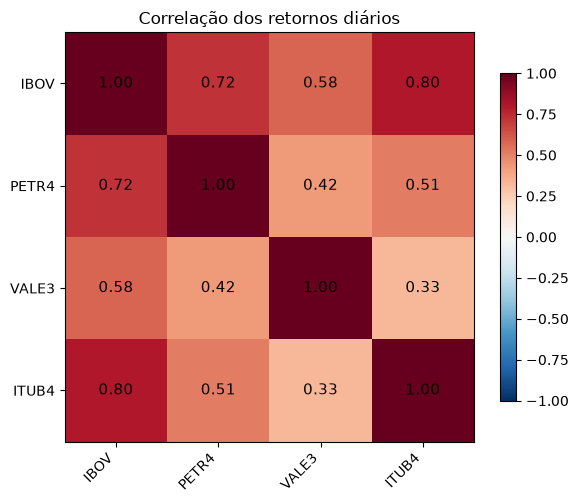

Ticker,IBOV,PETR4,VALE3,ITUB4
Ticker,,,,
IBOV,1.000000,0.721101,0.580379,0.797362
PETR4,0.721101,1.000000,0.424753,0.512703
VALE3,0.580379,0.424753,1.000000,0.331794
ITUB4,0.797362,0.512703,0.331794,1.000000


In [8]:
corr = ret.corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.index)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=11)

fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlação dos retornos diários")
fig.tight_layout()
plt.show()

corr

## 4. Curvas de patrimônio (base 100)

R$ 100 investidos no primeiro pregão da amostra.

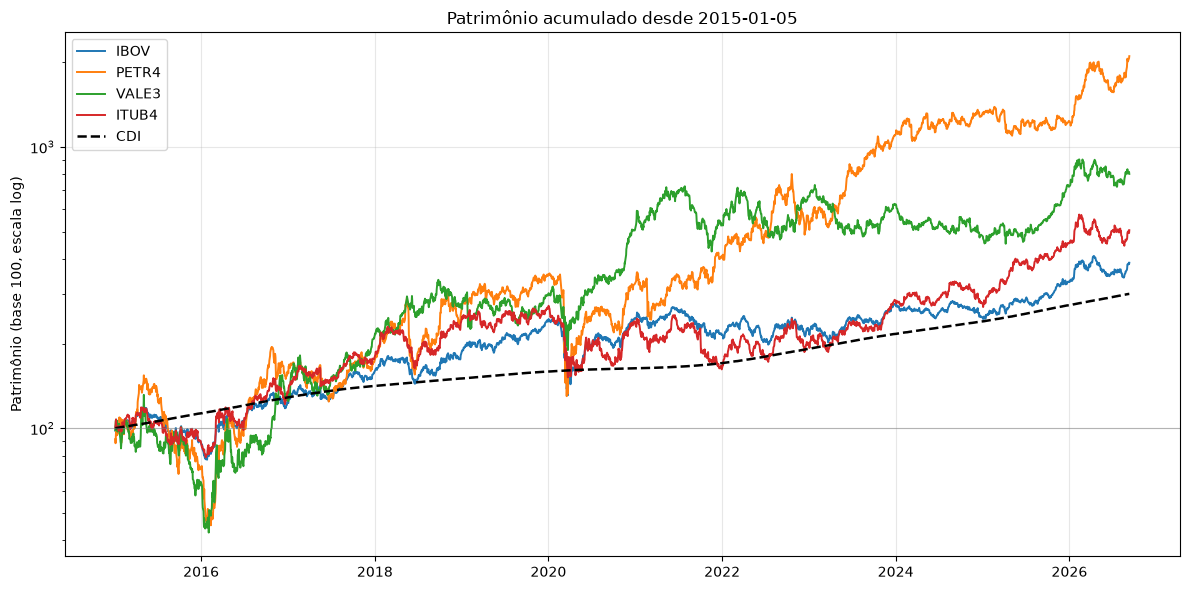

In [9]:
patrimonio = (1 + ret).cumprod() * 100
patrimonio_cdi = (1 + cdi).cumprod() * 100

fig, ax = plt.subplots(figsize=(12, 6))

for col in patrimonio.columns:
    ax.plot(patrimonio.index, patrimonio[col], label=col, linewidth=1.4)

ax.plot(patrimonio_cdi.index, patrimonio_cdi, label="CDI",
        color="black", linestyle="--", linewidth=1.8)

ax.axhline(100, color="gray", linewidth=0.8, alpha=0.5)
ax.set_yscale("log")
ax.set_ylabel("Patrimônio (base 100, escala log)")
ax.set_xlabel("")
ax.set_title(f"Patrimônio acumulado desde {patrimonio.index.min().date()}")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [10]:
# valor final de cada R$ 100
final = patrimonio.iloc[-1].copy()
final["CDI"] = patrimonio_cdi.iloc[-1]
final.sort_values(ascending=False).round(2)

Ticker
PETR4    2098.70
VALE3     801.00
ITUB4     504.94
IBOV      387.24
CDI       300.16
Name: 2026-09-10 00:00:00, dtype: float64